<a href="https://colab.research.google.com/github/rahulgopigerman17/PytorchPractice/blob/practice1/Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [149]:
import torch
import torch.nn as nn
import pandas as pd

In [150]:
# Model
class Model(nn.Module):
  def __init__(self, n_features, h1, h2, h3, out_classes):
    super(Model, self).__init__()
    self.fc1 = nn.Linear(in_features=n_features, out_features=h1)
    self.fc2 = nn.Linear(in_features=h1, out_features=h2)
    self.fc3 = nn.Linear(in_features=h2, out_features = h3)
    self.out = nn.Linear(in_features=h3, out_features=out_classes)

  def forward(self, x):
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    x = torch.relu(self.fc3(x))
    out = self.out(x)
    return out

In [151]:
model = Model(n_features=4, h1=10, h2=20, h3=20, out_classes=3)

In [152]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [153]:
df['species'] = df['species'].replace({'setosa': 0, 'versicolor': 1, 'virginica': 2})
df

<ipython-input-153-58e866dd4138>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['species'] = df['species'].replace({'setosa': 0, 'versicolor': 1, 'virginica': 2})


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [154]:
torch.manual_seed(10)

In [155]:
X = df.drop('species', axis=1)
Y = df['species']

In [156]:
X = torch.tensor(X.values, dtype=torch.float32)
Y = torch.tensor(Y.values, dtype=torch.long)
#Y = torch.reshape(Y, (-1, 1))
print(X.shape)
print(Y.shape)

torch.Size([150, 4])
torch.Size([150])


In [157]:
from sklearn.model_selection import train_test_split

In [158]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

torch.Size([120, 4])
torch.Size([30, 4])
torch.Size([120])
torch.Size([30])


In [159]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [160]:
num_epochs = 100
losses = []
for epoch in range(num_epochs):
  Y_pred = model(X_train)
  loss = criterion(Y_pred, Y_train)
  losses.append(loss.item())
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if (epoch+1) % 10 == 0:
    print(f'Epoch: {epoch+1}, Loss: {loss.item()}')

Epoch: 10, Loss: 0.8404892683029175
Epoch: 20, Loss: 0.479603111743927
Epoch: 30, Loss: 0.20804694294929504
Epoch: 40, Loss: 0.08582506328821182
Epoch: 50, Loss: 0.0629081279039383
Epoch: 60, Loss: 0.057945366948843
Epoch: 70, Loss: 0.05541099235415459
Epoch: 80, Loss: 0.0539248064160347
Epoch: 90, Loss: 0.052703991532325745
Epoch: 100, Loss: 0.052057113498449326


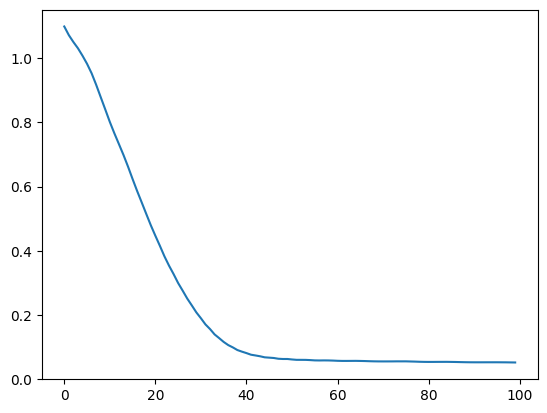

In [161]:
from matplotlib.pyplot import plot
%matplotlib inline
plot(losses)

In [162]:
correct = 0
evallosses = []
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_pred = model(data)
    evalloss = criterion(y_pred, Y_test[i])
    print(f'Eval Loss: {evalloss.item()}')
    evallosses.append(evalloss.item())
    prediction = torch.argmax(y_pred)
    if prediction == Y_test[i]:
      correct += 1
print(f'Correct: {correct}/{len(X_test)}')

Eval Loss: 0.006082713603973389
Eval Loss: 0.0020998113323003054
Eval Loss: 0.00014673586701974273
Eval Loss: 0.0016972911544144154
Eval Loss: 0.00025245340657420456
Eval Loss: 0.0005727558163926005
Eval Loss: 0.615617573261261
Eval Loss: 0.00013410145766101778
Eval Loss: 0.00023100091493688524
Eval Loss: 0.0039222706109285355
Eval Loss: 0.01778172329068184
Eval Loss: 0.0010307481279596686
Eval Loss: 0.005725768860429525
Eval Loss: 0.00035291642416268587
Eval Loss: 0.00018225439998786896
Eval Loss: 0.0012834176886826754
Eval Loss: 0.0009234455064870417
Eval Loss: 0.00045599075383506715
Eval Loss: 0.00022766382608097047
Eval Loss: 0.00024923557066358626
Eval Loss: 0.00018857131362892687
Eval Loss: 9.775113539944869e-06
Eval Loss: 0.26962751150131226
Eval Loss: 0.0003591130953282118
Eval Loss: 0.0006092122639529407
Eval Loss: 0.0003165697562508285
Eval Loss: 0.00013743886665906757
Eval Loss: 0.004318554885685444
Eval Loss: 0.0022597985807806253
Eval Loss: 0.00027771908207796514
Correct: 

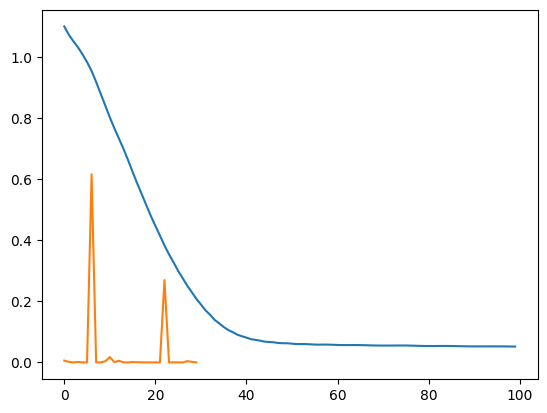

In [163]:
plot(losses)
plot(evallosses)